# Characterization of Alternative Splicing in High-Risk Wilms’ Tumors - Figure 1
Author: Yaron Trink



In this notebook we will reproduce Figure 1 from the paper "Characterization of Alternative Splicing in High-Risk Wilms’ Tumors".

### Part 1 - project tumor and normal samples, as well as precomputed archetypes (see preprocessing) onto gene expression latent space using PCA.

In [44]:
import os
os.chdir(r'C:\Users\trinkya\OneDrive - Bar Ilan University\github\paper2_splicing\src\figure_1')
print('figure_1' in os.getcwd()) # this should be figure 1

import wilms_module_1 as wilms
import matplotlib.pyplot as plt
import pandas as pd
import collections
import numpy as np
from itertools import cycle

from importlib import reload
from typing import List, Dict, Literal, Optional


True


In [48]:
reload(wilms)


<module 'wilms_module_1' from 'c:\\Users\\trinkya\\OneDrive - Bar Ilan University\\github\\paper2_splicing\\src\\figure_1\\wilms_module_1.py'>

Selected genes from fetal kidney development, and metadata for all samples.

In [3]:
selectedGenes= pd.read_csv('../data/selected_genes_annotated.csv')['Selected genes']
metadata = pd.read_csv('../data/metadataAll.csv',index_col=0,keep_default_na=False)
metadata.head()

,Unnamed: 0,File Name,Data Category,Data Type,Project ID,Case ID,Sample ID,Sample Type,downstream_analyses,access,...,Proliferating cap mesenchyme,Proximal tubule,UB,Macrophage,Fibroblast,Myofibroblast,Renal Vesicle,S-shaped body,Histologic Classification of Primary Tumor Normals Labelled,Manual Classification
0426f468_cb4e_454e_b3a0_e8f7e2759090,0,e7a4cd6c-f984-4369-b2c0-22ca61782934.rna_seq.g...,Sequencing Reads,Aligned Reads,TARGET-WT,TARGET-50-PAJNEC,TARGET-50-PAJNEC-01A,Primary Tumor,[{'output_files': [{'file_id': '60462da7-04f8-...,controlled,...,0.119009,0.030816,0.087566,0.073213,0.076629,0.098232,0.101184,0.084671,FHWT,Unspecified Continuum
052a62a7_4abe_4fae_9e02_043845b6a103,1,f5401108-0ad3-427c-981c-6750edc0ee79.rna_seq.g...,Sequencing Reads,Aligned Reads,TARGET-WT,TARGET-50-PAJPAU,TARGET-50-PAJPAU-01A,Primary Tumor,[{'output_files': [{'file_id': 'f7c342bc-7b0e-...,controlled,...,0.120921,0.052821,0.081677,0.059759,0.065824,0.091484,0.114027,0.088453,FHWT,Unspecified Continuum
07049ec7_b2e0_4047_aadf_c3b5b6094840,2,e8a8c5e4-1025-4664-b686-95543d247da1.rna_seq.g...,Sequencing Reads,Aligned Reads,TARGET-WT,TARGET-50-PAJLIP,TARGET-50-PAJLIP-01A,Primary Tumor,[{'output_files': [{'file_id': 'f67a2952-3d2c-...,controlled,...,0.139717,0.036131,0.069928,0.045766,0.077844,0.086885,0.125107,0.094082,DAWT,Unspecified Continuum
09a75bd3_f5ea_4bf5_92ef_4a67b39512a2,3,625c7735-d623-4ae6-94f2-dafb7f1edbe4.rna_seq.g...,Sequencing Reads,Aligned Reads,TARGET-WT,TARGET-50-PAKPDF,TARGET-50-PAKPDF-01A,Primary Tumor,[{'output_files': [{'file_id': 'a4b30dcb-bad0-...,controlled,...,0.138241,0.033164,0.070146,0.051119,0.082138,0.090739,0.118274,0.090896,DAWT,Unspecified Continuum
0aa9c2f6_1cf2_40cc_a443_8a8a36902bec,4,0a698bc4-c0bf-4ee2-a8c8-c60efbb914d0.rna_seq.g...,Sequencing Reads,Aligned Reads,TARGET-WT,TARGET-50-PAJMEP,TARGET-50-PAJMEP-01A,Primary Tumor,[{'output_files': [{'file_id': 'fa2b1af4-25d7-...,controlled,...,0.129034,0.041827,0.074017,0.052267,0.087308,0.091880,0.116041,0.091464,FHWT,Unspecified Continuum


Read normalized counts matrix for all samples and three archetypes.

In [4]:
dfExpression = pd.read_csv('../data/tcga_counts_all_threeArcs.csv',index_col=0)
dfExpression.head()

,0426f468_cb4e_454e_b3a0_e8f7e2759090,052a62a7_4abe_4fae_9e02_043845b6a103,07049ec7_b2e0_4047_aadf_c3b5b6094840,09a75bd3_f5ea_4bf5_92ef_4a67b39512a2,0aa9c2f6_1cf2_40cc_a443_8a8a36902bec,0d7fd6f7_d7c0_43bf_b740_ebd57e3f53c1,0ff5f0f2_3e27_4cde_864d_06251fca3c4f,127f26ca_8c9b_451e_b7c0_a213d2751bb2,17095282_6f34_4579_9367_503fb9badffb,182525a6_5342_4b83_892d_1900c2228927,...,efe11933_cd14_4567_be67_eca0f284d8b6,f2213b1f_2f39_4b6e_8270_75542f2336a5,f4d94db3_214b_40b8_9089_8e64796294f7,f63b2756_95e4_440d_a4a9_4106401170df,f6b5f070_1ba1_4e83_a213_f09b26a97d82,f8c8f276_57a4_4d22_89cf_a7dff98a8b65,faae6431_c880_493d_88b8_8e6e6896ced1,Arc1_Blast,Arc2_Stromal,Arc3_Normal
Row,,,,,,,,,,,,,,,,,,,,,
A1BG,9.654071,6.994730,8.667359,7.661863,6.085147,7.321999,7.567837,8.630450,7.648235,7.306781,...,5.775305,7.424918,7.534371,8.904307,8.429077,5.594030,8.263019,7.086259,8.350367,7.348861
A1BG-AS1,2.099102,4.657056,5.392753,5.341597,4.366744,5.434577,4.585947,5.462132,4.692311,4.906007,...,1.761184,4.493333,3.983363,5.098266,6.095327,1.919343,2.983074,4.338660,2.766183,3.870869
A1CF,2.099102,2.198368,3.809404,2.924387,1.295224,4.761138,5.871375,2.653249,1.352402,8.664297,...,4.637937,5.740456,4.056557,2.935669,3.099270,1.513493,4.191147,1.260512,2.871433,6.803897
A2M,12.719373,14.692157,12.783668,13.388363,14.178634,14.343251,12.732304,12.653000,12.498094,15.635613,...,14.283291,14.680016,13.191677,13.846061,14.657695,13.975075,11.983108,12.797229,13.817475,15.458543
A2M-AS1,8.052005,8.818565,7.366766,7.802375,7.097643,8.984263,9.367239,7.892242,8.534116,8.653213,...,7.435153,8.426367,8.549617,6.870672,9.033635,9.064046,8.954137,7.912224,6.909849,8.894508


In [22]:
res = wilms.run_pca_on_normalized_counts(
    dfExpression,
    n_components=3,
    n_arcs=3,                         
    exclude_archetypes_from_pca=False, 
    center=False,
    scale=False,
    log1p=False,
    random_state=0
)

PC = res["PC"]                                
explained = res["explained_variance_ratio"]   
arcs = res["archetype_cols"]    

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'PCA (2D)'}, xlabel='PC1', ylabel='PC2'>)

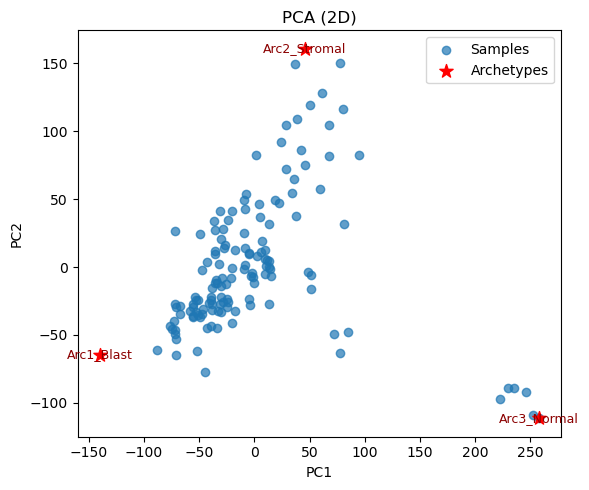

In [23]:
wilms.plot_pca2d(res, save_to_file=False, folder="results", file_end="wilms_pca", file_type="svg")


### Part 2 - identify identity of gene expression archetypes

To identify the archetypes, the size and color of each sample (dot) are drawn according to expression levels of known genes marking the cell populations of the fetal developing kidney (large red—high expression; small blue—low expression).

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'UMOD'}, xlabel='PC1', ylabel='PC2'>)

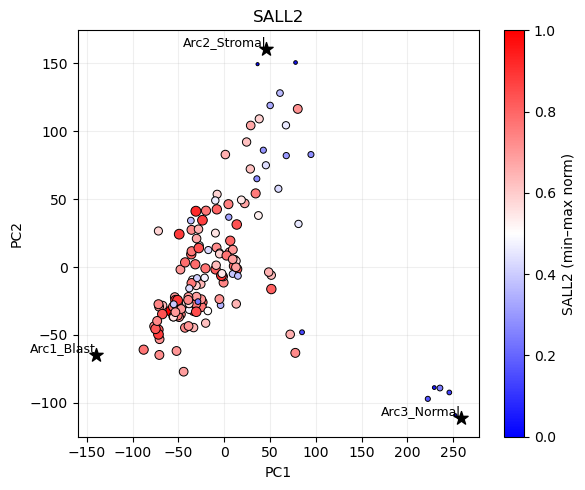

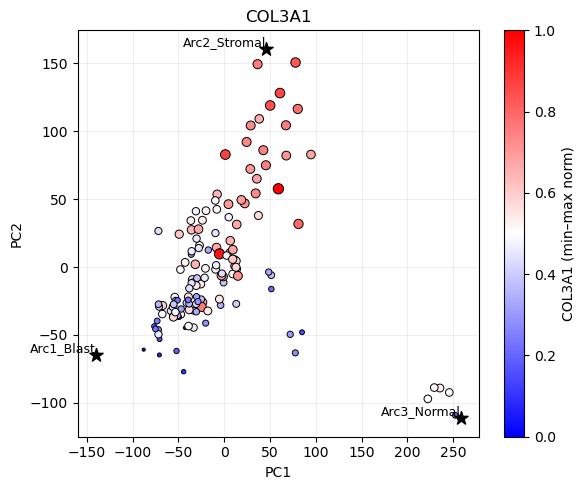

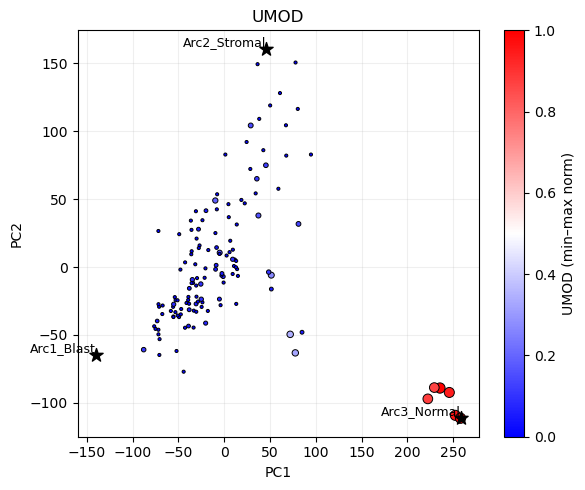

In [35]:

genes_to_plot = ["SALL2", "COL3A1", "UMOD"]

wilms.plot_gene_expression2d(
    pca_result=res,
    counts=dfExpression,
    genes=genes_to_plot,
    save_to_file=False
)

Histological classification - We did not observe a significant separation between relapsed favorable histology Wilms’ tumors (FHWTs) and diffuse anaplastic Wilms’ tumors (DAWTs) in this dataset.

Saved: results/plots\pca2d_by_subtype.svg


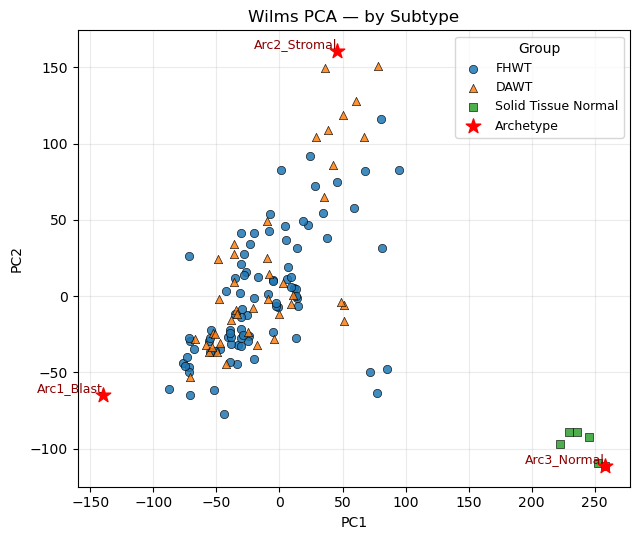

In [43]:
sample_list = metadata.loc[:,'Histologic Classification of Primary Tumor Normals Labelled'].tolist()

fig, ax = wilms.plot_categorical_pca2d(
    pca_result=res,
    labels=sample_list,                   
    save_to_file=True,
    folder="results/plots",
    file_end="pca2d_by_subtype",
    file_type="svg",
    title="Wilms PCA — by Subtype"
)


Unsupervised differential gene expression - To identify genes that are specifically up-regulated in each archetype, we performed differential expression analysis comparing each archetype to all other samples.

In [50]:
samples = ["Arc1_Blast",'Arc2_Stromal','Arc3_Normal']

# Up-regulated genes where sample > ALL others by > 1 log2FC
res_all = wilms.diff_expression_one_vs_all(
    counts=dfExpression,
    samples=samples,
    threshold=1.0,               
    direction="both",              
    mode="pairwise_all",           
    save_path=None  
)



These genes can be used as input to toppgene
https://toppgene.cchmc.org/